# Regression

Regression in machine learning is a supervised learning technique used to predict continuous numerical values such as, house prices or fuel efficiency, by modeling relationships between input features and a target variable. It includes methods like linear, multiple, polynomial, ridge and lasso regression

This notebook will carry out a Simple linear regression with automobile data. Linear regression is a statistical method that models the relationship between a dependent variable and one or more independent variables using a best‑fit linear equation such as y = mx + c. Whereas Simple linear regression models the relationship between one independent variable X and one dependent variable Y using a best‑fit straight line estimated by Ordinary Least Squares (OLS), typically written as ŷ = β₀ + β₁X.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
matplotlib.style.use('ggplot')
from sklearn.linear_model import LinearRegression

We will now use sklearn to predict automobile mileage per gallon (mpg) and evaluate these predictions. We first load the data and split them into a training set and a testing set.

In [14]:
#load mtcars
dfcars=pd.read_csv("mtcars.csv")
dfcars=dfcars.rename(columns={"Unnamed: 0":"name"})
dfcars.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


>**EXERCISE:**  Pick one variable to use as a predictor for simple linear regression.  Create a markdown cell below and discuss your reasons.  You may want to justify this with some visualizations.  Is there a second variable you'd like to use as well, say for multiple linear regression with two predictors?

In [15]:
for col in dfcars.columns.drop(["name", "mpg"]):
    print(f"Correlation of {col} with mpg:", dfcars[col].corr(dfcars["mpg"]))

Correlation of cyl with mpg: -0.8521619594266132
Correlation of disp with mpg: -0.8475513792624785
Correlation of hp with mpg: -0.7761683718265864
Correlation of drat with mpg: 0.6811719078067494
Correlation of wt with mpg: -0.8676593765172281
Correlation of qsec with mpg: 0.41868403392177816
Correlation of vs with mpg: 0.6640389191275927
Correlation of am with mpg: 0.599832429454648
Correlation of gear with mpg: 0.4802847573388421
Correlation of carb with mpg: -0.5509250739024586


chose wt because it has the strongest correlation with mpg (-0.87)

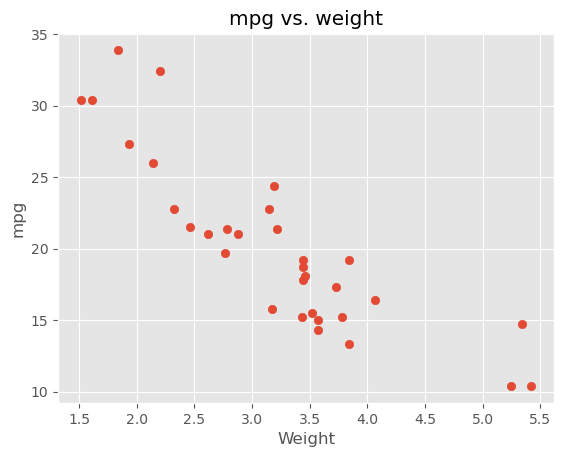

In [16]:
plt.scatter(dfcars["wt"], dfcars["mpg"])
plt.xlabel("Weight")
plt.ylabel("mpg")
plt.title("mpg vs. weight")
plt.show()

The scatter plot shows a clear downward trend, so a linear model is reasonable

> **EXERCISE:** With sklearn fit the training data using simple linear regression. 

> Plot the data and the prediction.  

>Print out the mean squared error for the set

In [17]:
# define predictor and response for the set
X = dfcars[["wt"]]    # predictor: double brackets keep it 2D for sklearn
y = dfcars["mpg"]     # response

In [18]:
# Sanity check: confirm that X is 2D
X.ndim

2

In [19]:
# split into a training set and a testing set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [20]:
# create linear regression object with sklearn
regr = LinearRegression()

# train the model and make predictions
regr.fit(X_train, y_train)

train_preds = regr.predict(X_train)
test_preds = regr.predict(X_test)

# print out coefficients
print("Intercept:", regr.intercept_)
print("Slope (coefficient for wt):", regr.coef_[0])


Intercept: 36.77885777164089
Slope (coefficient for wt): -5.296308785394833


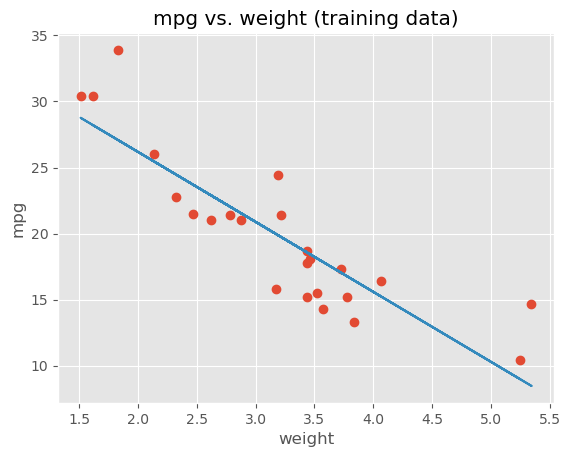

In [ ]:
# Plot outputs
pred = regr.predict(X_train)   # predicted mpg for the training cars

plt.plot(X_train, y_train, 'o')
plt.plot(X_train, pred)           
plt.xlabel("weight")
plt.ylabel("mpg")
plt.title("mpg vs. weight (training data)") 
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error as mse

train_mse = mse(y_train, pred)
print("Mean squared error (training set):", train_mse)

Mean squared error (training set): 8.075489261854512


The training MSE is 8.08, which corresponds to an RMSE of about 2.8 mpg, meaning predictions are typically off by around 2.8 mpg. Together with an R² of 0.755, this shows weight is a good single predictor of mpg, though not a perfect one, since other factors also affect fuel efficiency.

In [23]:
test_pred = regr.predict(X_test)
print("Mean squared error (test set):", mse(y_test, test_pred))

Mean squared error (test set): 11.066073566315222


The test MSE is 11.07 (RMSE of about 3.3 mpg), which is higher than the training MSE of 8.08 (about 2.8 mpg), as expected, since the model was fitted to the training data. The two values are reasonably close, suggesting the model generalises fairly well to unseen cars. Because the test set is small (8 cars), this estimate may vary with a different split

In [24]:
from sklearn.metrics import r2_score as r2
r2(y_train, pred)

0.7554393819672603

weight accounts for roughly three-quarters of the differences in mpg. The remaining ~25% comes from things the model doesn't know about, like horsepower, engine size, or transmission type.